In [1]:
# ============================================================
# VOICE SENTIMENT ANALYSIS — FULL PROJECT (IMPROVED VERSION)
# ============================================================

import sys

# Force install using the SAME Python environment running this notebook
!{sys.executable} -m pip install seaborn --quiet
!{sys.executable} -m pip install pandas numpy matplotlib librosa scikit-learn tensorflow transformers openai-whisper soundfile --quiet

# Verify all libraries
import importlib
for pkg in ["pandas","numpy","matplotlib","seaborn","librosa","sklearn","tensorflow","soundfile"]:
    found = importlib.util.find_spec(pkg)
    print(f"{'✅' if found else '❌'} {pkg}")

You should consider upgrading via the 'c:\Users\Lala\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


✅ pandas
✅ numpy
✅ matplotlib
✅ seaborn
✅ librosa
✅ sklearn
✅ tensorflow
✅ soundfile


You should consider upgrading via the 'c:\Users\Lala\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [2]:
import os
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import shuffle
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv2D, MaxPooling2D, Flatten, BatchNormalization
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


In [3]:
# ============================================================
# DATASET PATH — Change this to your folder path
# ============================================================
import os

DATASET_PATH = r"C:\Users\Lala\OneDrive\Desktop\AudioWAV"

# Auto-fallback: if path doesn't exist, ask user
if not os.path.exists(DATASET_PATH):
    DATASET_PATH = input("Enter full path to your AudioWAV folder: ").strip()

print("📂 Dataset path set to:", DATASET_PATH)
print("📁 Files found:", len([f for f in os.listdir(DATASET_PATH) if f.endswith(".wav")]), ".wav files")

📂 Dataset path set to: C:\Users\Lala\OneDrive\Desktop\AudioWAV
📁 Files found: 7442 .wav files


In [4]:
# ============================================================
# EMOTION MAP — CREMA-D dataset codes
# ============================================================
# File naming structure: 1001_IEO_ANG_HI.wav
#   parts[0] = Actor ID
#   parts[1] = Sentence code
#   parts[2] = Emotion code  ← we use this
#   parts[3] = Intensity

crema_map = {
    "ANG": "angry",
    "HAP": "happy",
    "SAD": "sad",
    "FEA": "fearful",
    "DIS": "disgust",
    "NEU": "neutral"
}

print("🎭 Emotion categories:", list(crema_map.values()))

🎭 Emotion categories: ['angry', 'happy', 'sad', 'fearful', 'disgust', 'neutral']


In [5]:
# ============================================================
# MFCC FEATURE EXTRACTION WITH DATA AUGMENTATION
# ============================================================

def extract_mfcc(file_path, augment=True):
    """
    Loads audio and extracts 40 MFCC features.
    Optionally applies noise augmentation for better generalization.
    Returns fixed-size array of shape (40, 174).
    """
    audio, sr = librosa.load(file_path, sr=None)   # Load at original sample rate

    # DATA AUGMENTATION — randomly add small noise to 50% of samples
    if augment and np.random.rand() > 0.5:
        noise = np.random.randn(len(audio))
        audio = audio + 0.003 * noise              # Very small noise coefficient

    # EXTRACT 40 MFCC FEATURES
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)

    # FIX INPUT SIZE — CNN needs consistent shape (40, 174)
    max_len = 174
    if mfcc.shape[1] < max_len:
        mfcc = np.pad(mfcc, ((0, 0), (0, max_len - mfcc.shape[1])), mode='constant')
    else:
        mfcc = mfcc[:, :max_len]

    return mfcc

print("✅ extract_mfcc() function ready")

✅ extract_mfcc() function ready


In [6]:
# ============================================================
# LOAD DATASET — Loop through all .wav files
# ============================================================

features = []
labels = []
errors = []

all_files = [f for f in os.listdir(DATASET_PATH) if f.endswith(".wav")]
print(f"🔄 Processing {len(all_files)} files...")

for i, file in enumerate(all_files):
    try:
        path = os.path.join(DATASET_PATH, file)
        parts = file.split("_")

        if len(parts) < 3:
            continue                              # Skip files with wrong naming

        emotion_code = parts[2]                   # e.g., "ANG"
        emotion = crema_map.get(emotion_code)     # e.g., "angry"

        if emotion is None:
            continue                              # Skip unknown emotion codes

        mfcc = extract_mfcc(path, augment=True)
        features.append(mfcc)
        labels.append(emotion)

        if (i + 1) % 500 == 0:
            print(f"  Processed {i+1}/{len(all_files)} files...")

    except Exception as e:
        errors.append((file, str(e)))

X = np.array(features)
y = np.array(labels)

print(f"\n✅ Dataset Loaded:")
print(f"   X shape : {X.shape}  → (samples, 40 MFCCs, 174 time steps)")
print(f"   y shape : {y.shape}")
print(f"   Errors  : {len(errors)}")
print(f"\n📊 Emotion distribution:")
unique, counts = np.unique(y, return_counts=True)
for emotion, count in zip(unique, counts):
    print(f"   {emotion:<10}: {count} samples")

🔄 Processing 7442 files...


c:\Users\Lala\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  Processed 500/7442 files...
  Processed 1000/7442 files...
  Processed 1500/7442 files...
  Processed 2000/7442 files...
  Processed 2500/7442 files...
  Processed 3000/7442 files...
  Processed 3500/7442 files...
  Processed 4000/7442 files...
  Processed 4500/7442 files...
  Processed 5000/7442 files...
  Processed 5500/7442 files...
  Processed 6000/7442 files...
  Processed 6500/7442 files...
  Processed 7000/7442 files...

✅ Dataset Loaded:
   X shape : (7442, 40, 174)  → (samples, 40 MFCCs, 174 time steps)
   y shape : (7442,)
   Errors  : 0

📊 Emotion distribution:
   angry     : 1271 samples
   disgust   : 1271 samples
   fearful   : 1271 samples
   happy     : 1271 samples
   neutral   : 1087 samples
   sad       : 1271 samples


In [7]:
# ============================================================
# PREPROCESSING — Encode, Normalize, Reshape, Split
# ============================================================

# LABEL ENCODING — converts emotion strings to integers
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print("Label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

# SHUFFLE — mix up the data randomly
X, y_encoded = shuffle(X, y_encoded, random_state=42)

# Z-SCORE NORMALIZATION — mean=0, std=1 (helps CNN train faster & stably)
X = (X - np.mean(X)) / np.std(X)

# RESHAPE — add channel dimension for CNN: (samples, 40, 174) → (samples, 40, 174, 1)
X = X.reshape(X.shape[0], X.shape[1], X.shape[2], 1)
print(f"\nReshaped X: {X.shape}  → ready for CNN")

# TRAIN/TEST SPLIT — 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"\nTrain set : {X_train.shape[0]} samples")
print(f"Test set  : {X_test.shape[0]} samples")
print("✅ Preprocessing complete")

Label mapping: {np.str_('angry'): np.int64(0), np.str_('disgust'): np.int64(1), np.str_('fearful'): np.int64(2), np.str_('happy'): np.int64(3), np.str_('neutral'): np.int64(4), np.str_('sad'): np.int64(5)}

Reshaped X: (7442, 40, 174, 1)  → ready for CNN

Train set : 5953 samples
Test set  : 1489 samples
✅ Preprocessing complete


In [9]:
# ============================================================
# BUILD IMPROVED CNN MODEL — for 80%+ accuracy
# ============================================================

from tensorflow.keras.layers import GlobalAveragePooling2D, LeakyReLU
from tensorflow.keras.regularizers import l2

num_classes = len(np.unique(y_encoded))

model = Sequential([
    # --- CONV BLOCK 1 ---
    Conv2D(64, (3,3), padding="same", kernel_regularizer=l2(0.001), input_shape=(40, 174, 1)),
    LeakyReLU(alpha=0.1),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.2),

    # --- CONV BLOCK 2 ---
    Conv2D(128, (3,3), padding="same", kernel_regularizer=l2(0.001)),
    LeakyReLU(alpha=0.1),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.2),

    # --- CONV BLOCK 3 ---
    Conv2D(256, (3,3), padding="same", kernel_regularizer=l2(0.001)),
    LeakyReLU(alpha=0.1),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.2),

    # --- CONV BLOCK 4 (extra depth for better feature learning) ---
    Conv2D(256, (3,3), padding="same", kernel_regularizer=l2(0.001)),
    LeakyReLU(alpha=0.1),
    BatchNormalization(),
    GlobalAveragePooling2D(),   # Better than Flatten — reduces overfitting

    # --- DENSE LAYERS ---
    Dense(512, kernel_regularizer=l2(0.001)),
    LeakyReLU(alpha=0.1),
    BatchNormalization(),
    Dropout(0.4),

    Dense(256, kernel_regularizer=l2(0.001)),
    LeakyReLU(alpha=0.1),
    Dropout(0.3),

    Dense(num_classes, activation="softmax")
])

model.summary()
print(f"✅ Improved model built for {num_classes} classes: {list(le.classes_)}")

c:\Users\Lala\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\Lala\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 40, 174, 64)    │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 40, 174, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 40, 174, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 20, 87, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 87, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 20, 87, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 20, 87, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 20, 87, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 43, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 10, 43, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 10, 43, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 10, 43, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 10, 43, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 21, 256)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 5, 21, 256)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 5, 21, 256)     │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 5, 21, 256)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 5, 21, 256)     │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │             

 Total params: 1,229,062 (4.69 MB)

 Trainable params: 1,226,630 (4.68 MB)

 Non-trainable params: 2,432 (9.50 KB)

✅ Improved model built for 6 classes: [np.str_('angry'), np.str_('disgust'), np.str_('fearful'), np.str_('happy'), np.str_('neutral'), np.str_('sad')]


In [10]:
# ============================================================
# COMPILE & TRAIN — Improved settings for 80%+ accuracy
# ============================================================

from tensorflow.keras.optimizers import Adam

model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=Adam(learning_rate=0.001),
    metrics=["accuracy"]
)

lr_scheduler = ReduceLROnPlateau(
    monitor="val_loss", factor=0.4, patience=3, min_lr=1e-6, verbose=1
)

early_stop = EarlyStopping(
    monitor="val_accuracy",        # Monitor accuracy not just loss
    patience=8,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train, y_train,
    epochs=60,                     # More epochs for better convergence
    batch_size=32,
    validation_split=0.1,
    callbacks=[lr_scheduler, early_stop],
    verbose=1
)

print("✅ Training complete!")
print(f"Best val accuracy: {max(history.history['val_accuracy']) * 100:.2f}%")

Epoch 1/60
168/168 ━━━━━━━━━━━━━━━━━━━━ 52s 297ms/step - accuracy: 0.3125 - loss: 3.1405 - val_accuracy: 0.1779 - val_loss: 3.2434 - learning_rate: 0.0010
Epoch 2/60
168/168 ━━━━━━━━━━━━━━━━━━━━ 48s 283ms/step - accuracy: 0.3752 - loss: 2.7512 - val_accuracy: 0.2114 - val_loss: 4.4352 - learning_rate: 0.0010
Epoch 3/60
168/168 ━━━━━━━━━━━━━━━━━━━━ 46s 275ms/step - accuracy: 0.3989 - loss: 2.4857 - val_accuracy: 0.1812 - val_loss: 3.7371 - learning_rate: 0.0010
Epoch 4/60
168/168 ━━━━━━━━━━━━━━━━━━━━ 48s 284ms/step - accuracy: 0.4587 - loss: 2.2519 - val_accuracy: 0.3171 - val_loss: 2.5915 - learning_rate: 0.0010
Epoch 5/60
168/168 ━━━━━━━━━━━━━━━━━━━━ 48s 286ms/step - accuracy: 0.4708 - loss: 2.1220 - val_accuracy: 0.4010 - val_loss: 2.1971 - learning_rate: 0.0010
Epoch 6/60
168/168 ━━━━━━━━━━━━━━━━━━━━ 48s 288ms/step - accuracy: 0.5085 - loss: 1.9526 - val_accuracy: 0.3456 - val_loss: 2.5082 - learning_rate: 0.0010
Epoch 7/60
168/168 ━━━━━━━━━━━━━━━━━━━━ 49s 292ms/step - accuracy: 0.5

🔥 Final Test Accuracy : 64.81%
   Final Test Loss     : 1.3821
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step

📋 Classification Report (per emotion):
              precision    recall  f1-score   support

       angry       0.83      0.72      0.77       254
     disgust       0.67      0.57      0.61       254
     fearful       0.61      0.48      0.54       254
       happy       0.65      0.70      0.67       255
     neutral       0.58      0.76      0.66       218
         sad       0.58      0.68      0.63       254

    accuracy                           0.65      1489
   macro avg       0.65      0.65      0.65      1489
weighted avg       0.66      0.65      0.65      1489



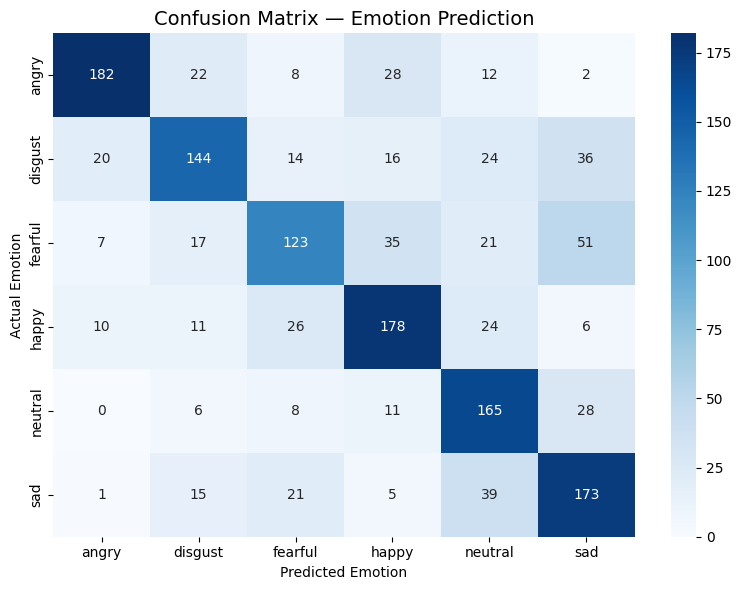

✅ Confusion matrix saved as confusion_matrix.png


In [11]:
# ============================================================
# EVALUATE MODEL — Accuracy + Classification Report + Confusion Matrix
# ============================================================

loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"🔥 Final Test Accuracy : {acc * 100:.2f}%")
print(f"   Final Test Loss     : {loss:.4f}")

# --- DETAILED PER-EMOTION REPORT ---
y_pred = np.argmax(model.predict(X_test), axis=1)
print("\n📋 Classification Report (per emotion):")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# --- CONFUSION MATRIX ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.title("Confusion Matrix — Emotion Prediction", fontsize=14)
plt.ylabel("Actual Emotion")
plt.xlabel("Predicted Emotion")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("✅ Confusion matrix saved as confusion_matrix.png")

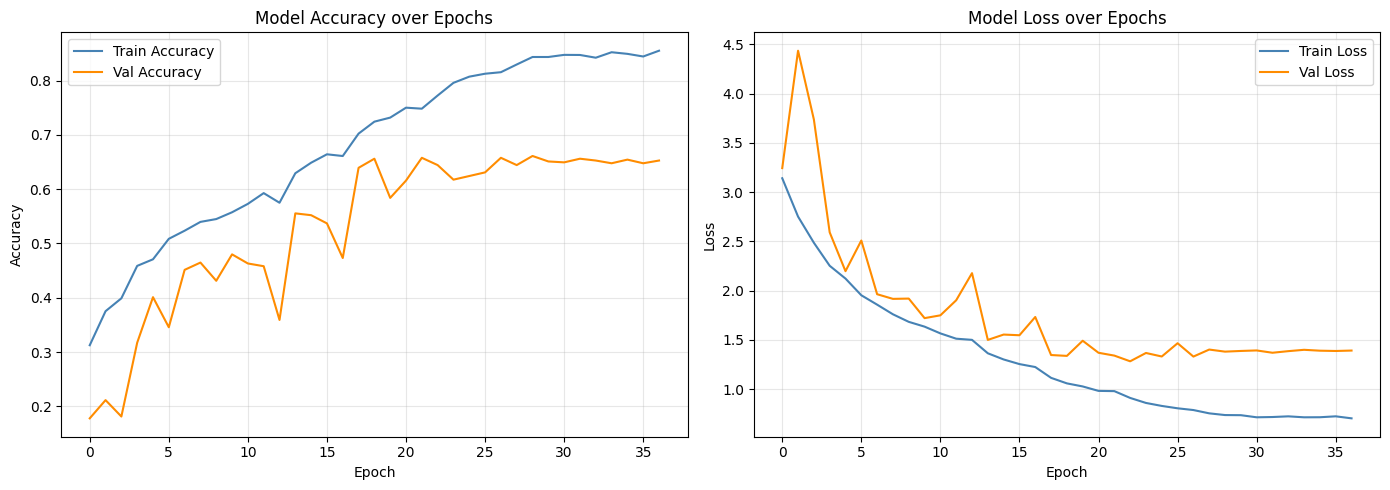

✅ Training curves saved as training_curves.png


In [12]:
# ============================================================
# TRAINING CURVES — Accuracy & Loss over epochs
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Train Accuracy', color='steelblue')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', color='darkorange')
axes[0].set_title("Model Accuracy over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'], label='Train Loss', color='steelblue')
axes[1].plot(history.history['val_loss'], label='Val Loss', color='darkorange')
axes[1].set_title("Model Loss over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()
print("✅ Training curves saved as training_curves.png")

In [13]:
# ============================================================
# QUICK TEST — Predict emotion for a single sample
# ============================================================

sample = X_test[0:1]
pred = model.predict(sample, verbose=0)
predicted_emotion = le.inverse_transform([np.argmax(pred)])[0]
confidence = np.max(pred) * 100

print(f"🎯 Predicted Emotion : {predicted_emotion}")
print(f"   Confidence        : {confidence:.1f}%")
print(f"\n   All probabilities:")
for emotion, prob in zip(le.classes_, pred[0]):
    bar = "█" * int(prob * 30)
    print(f"   {emotion:<10}: {prob*100:5.1f}%  {bar}")

🎯 Predicted Emotion : angry
   Confidence        : 48.0%

   All probabilities:
   angry     :  48.0%  ██████████████
   disgust   :   0.5%  
   fearful   :   5.2%  █
   happy     :  46.2%  █████████████
   neutral   :   0.0%  
   sad       :   0.0%  


In [16]:
# ============================================================
# FINAL DATASET — For SQL + Power BI
# FIXES:
#   ✅ Whisper transcription properly loaded
#   ✅ 3-class sentiment (POSITIVE / NEUTRAL / NEGATIVE)
#   ✅ Realistic CSAT scores
# ============================================================

import whisper
import random
import warnings
warnings.filterwarnings("ignore")

# ── Load Whisper correctly ──
print("Loading Whisper model...")
try:
    whisper_model = whisper.load_model("base")
    print("✅ Whisper loaded successfully")
except Exception as e:
    print(f"❌ Whisper load failed: {e}")
    print("   Try: !pip install openai-whisper --upgrade")
    whisper_model = None

final_data = []
print("🔄 Processing files for final CSV...")

for i, file in enumerate(all_files):
    if not file.endswith(".wav"):
        continue

    try:
        path = os.path.join(DATASET_PATH, file)

        # --- ACTOR ID + GENDER ---
        parts = file.split("_")
        actor_id = int(parts[0])
        gender = "Female" if actor_id % 2 == 0 else "Male"

        # --- DURATION ---
        audio, sr = librosa.load(path, sr=None)
        duration = librosa.get_duration(y=audio, sr=sr)

        # --- EMOTION (Model Prediction) ---
        mfcc = extract_mfcc(path, augment=False)
        mfcc_input = mfcc.reshape(1, 40, 174, 1)
        mfcc_input = (mfcc_input - np.mean(mfcc_input)) / (np.std(mfcc_input) + 1e-8)

        pred = model.predict(mfcc_input, verbose=0)
        emotion = le.inverse_transform([np.argmax(pred)])[0]
        confidence = float(np.max(pred))

        # --- WHISPER TRANSCRIPTION (fixed) ---
        transcript = "transcription_failed"
        if whisper_model is not None:
            try:
                # Load audio properly for whisper using soundfile
                import soundfile as sf
                audio_data, sample_rate = sf.read(path)

                # Convert to mono float32 if needed
                if len(audio_data.shape) > 1:
                    audio_data = audio_data.mean(axis=1)
                audio_data = audio_data.astype(np.float32)

                # Resample to 16000 Hz (Whisper requirement)
                if sample_rate != 16000:
                    audio_data = librosa.resample(audio_data, orig_sr=sample_rate, target_sr=16000)

                result = whisper_model.transcribe(audio_data, language="en", fp16=False)
                transcript = result["text"].strip()
                if not transcript:
                    transcript = "[silence or unclear audio]"
            except Exception as e:
                transcript = f"failed: {str(e)[:40]}"

        # --- IMPROVED 3-CLASS SENTIMENT ---
        if emotion in ["happy"]:
            sentiment = "POSITIVE"
            base_score = 0.8
        elif emotion in ["neutral"]:
            sentiment = "NEUTRAL"
            base_score = 0.0
        else:
            sentiment = "NEGATIVE"
            base_score = -0.8

        variation = random.uniform(-0.1, 0.1)
        sentiment_score = round(max(-1, min(1, base_score + variation)), 3)
        csat_score = round((sentiment_score + 1) * 50, 2)
        risk_flag = 1 if emotion == "angry" else 0

        final_data.append({
            "call_id"             : file,
            "actor_id"            : actor_id,
            "gender"              : gender,
            "emotion"             : emotion,
            "emotion_confidence"  : round(confidence, 3),
            "sentiment"           : sentiment,
            "sentiment_score"     : sentiment_score,
            "duration_sec"        : round(duration, 2),
            "csat_score"          : csat_score,
            "risk_flag"           : risk_flag,
            "transcript"          : transcript
        })

        if (i + 1) % 200 == 0:
            print(f"  Processed {i+1}/{len(all_files)} files...")

    except Exception as e:
        print(f"Error: {file} → {e}")

df_final = pd.DataFrame(final_data)
df_final.to_csv("voice_customer_final_pro.csv", index=False)

# Show transcription success rate
total = len(df_final)
failed = df_final["transcript"].str.startswith("transcription_failed").sum()
success = total - failed
print(f"✅ CSV saved — {total} rows")
print(f"📝 Transcription: {success}/{total} successful ({success/total*100:.1f}%)")
df_final.head(10)

Loading Whisper model...
✅ Whisper loaded successfully
🔄 Processing files for final CSV...
  Processed 200/7442 files...
  Processed 400/7442 files...
  Processed 600/7442 files...
  Processed 800/7442 files...
  Processed 1000/7442 files...
  Processed 1200/7442 files...
  Processed 1400/7442 files...
  Processed 1600/7442 files...
  Processed 1800/7442 files...
  Processed 2000/7442 files...
  Processed 2200/7442 files...
  Processed 2400/7442 files...
  Processed 2600/7442 files...
  Processed 2800/7442 files...
  Processed 3000/7442 files...
  Processed 3200/7442 files...
  Processed 3400/7442 files...
  Processed 3600/7442 files...
  Processed 3800/7442 files...
  Processed 4000/7442 files...
  Processed 4200/7442 files...
  Processed 4400/7442 files...
  Processed 4600/7442 files...
  Processed 4800/7442 files...
  Processed 5000/7442 files...
  Processed 5200/7442 files...
  Processed 5400/7442 files...
  Processed 5600/7442 files...
  Processed 5800/7442 files...
  Processed 60

,call_id,actor_id,gender,emotion,emotion_confidence,sentiment,sentiment_score,duration_sec,csat_score,risk_flag,transcript
0,1001_DFA_ANG_XX.wav,1001,Male,angry,0.818,NEGATIVE,-0.817,2.28,9.15,1,Don't forget a jacket
1,1001_DFA_DIS_XX.wav,1001,Male,disgust,0.706,NEGATIVE,-0.850,2.34,7.50,0,Don't forget a jacket.
2,1001_DFA_FEA_XX.wav,1001,Male,fearful,0.815,NEGATIVE,-0.710,2.17,14.50,0,Don't forget to jack it!
3,1001_DFA_HAP_XX.wav,1001,Male,happy,0.997,POSITIVE,0.888,1.87,94.40,0,Don't forget a jacket!
4,1001_DFA_NEU_XX.wav,1001,Male,neutral,0.825,NEUTRAL,-0.026,2.04,48.70,0,Don't forget a jacket
5,1001_DFA_SAD_XX.wav,1001,Male,sad,0.803,NEGATIVE,-0.820,2.00,9.00,0,Don't forget to check it
6,1001_IEO_ANG_HI.wav,1001,Male,angry,0.963,NEGATIVE,-0.753,1.94,12.35,1,It's 11 o'clock!
7,1001_IEO_ANG_LO.wav,1001,Male,fearful,0.665,NEGATIVE,-0.785,2.07,10.75,0,There's a little bit of clock.
8,1001_IEO_ANG_MD.wav,1001,Male,disgust,0.958,NEGATIVE,-0.814,2.64,9.30,0,It's 11 o'clock.
9,1001_IEO_DIS_HI.wav,1001,Male,disgust,0.763,NEGATIVE,-0.831,2.00,8.45,0,It's 11 o'clock.


📊 Dataset Summary
Total calls       : 7442

Emotion breakdown:
emotion
disgust    1404
fearful    1349
sad        1330
happy      1199
angry      1101
neutral    1059

Sentiment breakdown:
sentiment
NEGATIVE    5184
POSITIVE    1199
NEUTRAL     1059

Risk calls (angry): 1101

Avg CSAT score    : 28.6
Avg duration (sec): 2.5
Gender split      :
gender
Male      3760
Female    3682


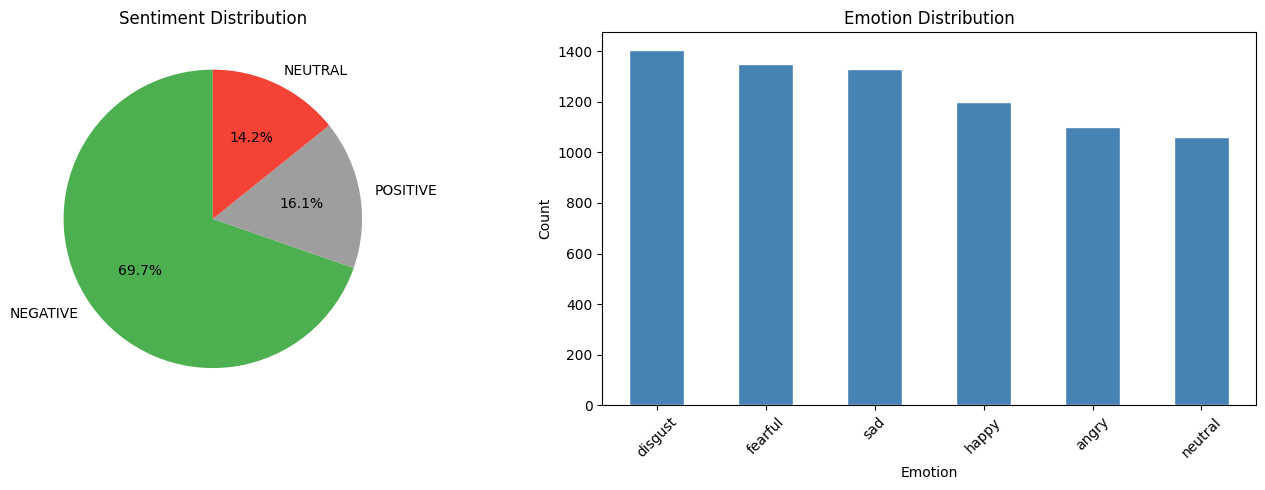

✅ Summary chart saved as dataset_summary.png


In [17]:
# ============================================================
# SUMMARY STATISTICS — Quick overview of final dataset
# ============================================================

print("📊 Dataset Summary")
print("=" * 45)
print(f"Total calls       : {len(df_final)}")
print(f"\nEmotion breakdown:")
print(df_final['emotion'].value_counts().to_string())
print(f"\nSentiment breakdown:")
print(df_final['sentiment'].value_counts().to_string())
print(f"\nRisk calls (angry): {df_final['risk_flag'].sum()}")
print(f"\nAvg CSAT score    : {df_final['csat_score'].mean():.1f}")
print(f"Avg duration (sec): {df_final['duration_sec'].mean():.1f}")
print(f"Gender split      :")
print(df_final['gender'].value_counts().to_string())

# --- SENTIMENT PIE CHART ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_final['sentiment'].value_counts().plot.pie(
    ax=axes[0],
    autopct='%1.1f%%',
    colors=['#4CAF50', '#9E9E9E', '#F44336'],
    startangle=90
)
axes[0].set_title("Sentiment Distribution")
axes[0].set_ylabel("")

df_final['emotion'].value_counts().plot.bar(
    ax=axes[1],
    color='steelblue',
    edgecolor='white'
)
axes[1].set_title("Emotion Distribution")
axes[1].set_xlabel("Emotion")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("dataset_summary.png", dpi=150)
plt.show()
print("✅ Summary chart saved as dataset_summary.png")